# Exercise: 1D Burgers Equation
The Cauchy Problem to be solved is the Burgers Equation 
\begin{align}
&\partial_t u (x,t) + u \partial_x u (x,t) - \nu \partial_x^2 u (x,t) = 0 \\
&u(t=0, x) = - \sin \left( \pi \, x \right) \\
&u\left(t, x=\pm 1\right) =  0
\end{align}
with $(t,x)\in[0,1]\times[−1,+1]$, and where we set
$$
\nu = \frac{0.01}{\pi}
$$

Extra: reviews on PINN

[1] https://www.nature.com/articles/s42254-021-00314-5

[2] https://arxiv.org/pdf/2202.06416.pdf

[3] https://www.mdpi.com/2504-2289/6/4/140

[4] https://medium.com/@vignesh.g1609/pinn-physics-informed-neural-networks-5f5f05bf7231

[5] https://ocw.mit.edu/courses/18-152-introduction-to-partial-differential-equations-fall-2011/29c6f7ee914a1d804899781f9f604f49_MIT18_152F11_lec_24.pdf , https://ocw.mit.edu/courses/18-152-introduction-to-partial-differential-equations-fall-2011/download/

In [1]:
# auto reload packages
%load_ext autoreload
%autoreload 2

In [2]:
from typing import Type, Union
import gc
import math
from collections import OrderedDict
import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
from utils.burgers_pde import Burgers_PDE
from utils.burgers_bc  import Burgers_BC

In [4]:
from utils.pinn_lightning import HeatPINNLightning

In [5]:
from typing import List, Tuple

class BurgersPINNLightning(HeatPINNLightning):
    def __init__(
        self,
        # Geometry
        time_interval : Tuple[float] = (0.0, 1.0),
        space_interval: Tuple[float] = (-1.0, 1.0),
        # Network
        n_inputs : int = 2,
        n_outputs: int = 1,
        hidden_layers: Tuple[int] = (32, 32, 32),
        activation_func=nn.Tanh,
        # PDE
        diffusion_coefficient: float = 0.5,
        # Loss components
        fun_batch_size: int = 4096,
        pde_batch_size: int = 4096,
        bc_batch_size : int = 1024,
        ic_batch_size : int = 1024,
        # SoftAdapt
        use_softadapt: bool = False,
        softadapt_start_epoch: int = 5,
        # Optimizer
        learning_rate: float = 1e-3,
        # sampler
        use_r2: bool = False, 
    ):
        super().__init__(
            # Geometry
            time_interval  = time_interval,
            space_interval = space_interval,
            # Network
            n_inputs  = n_inputs,
            n_outputs = n_outputs,
            hidden_layers   = hidden_layers,
            activation_func = activation_func,
            # PDE
            diffusion_coefficient = diffusion_coefficient,
            # Loss components
            use_rec  = False,
            fun_batch_size = fun_batch_size,
            pde_batch_size = pde_batch_size,
            bc_batch_size  = bc_batch_size,
            ic_batch_size  = ic_batch_size,
            # SoftAdapt
            use_softadapt = use_softadapt,
            softadapt_start_epoch = softadapt_start_epoch,
            # Optimizer
            learning_rate = learning_rate,
            # sampler
            use_r2 = use_r2, 
        )
        self.save_hyperparameters()
        # change  PDE + BC/IC
        self.pde   = Burgers_PDE(D=np.sqrt(diffusion_coefficient) )
        self.bc_ic = Burgers_BC(cost_function=nn.MSELoss())
    

In [6]:
import lightning as L
from lightning.pytorch.loggers   import CSVLogger
from lightning.pytorch.callbacks import RichProgressBar, ModelCheckpoint

In [8]:
model = BurgersPINNLightning(
    hidden_layers=(64, 64, 64, 64, 64),
    #
    diffusion_coefficient=0.01/torch.pi,
    #
    fun_batch_size=4096,
    pde_batch_size=4096,
    bc_batch_size=4096,
    ic_batch_size=4096,
    #
    use_softadapt=False,
    #
    learning_rate=0.001,
    use_r2 = False,
)

In [9]:
# loggger
pl_logger = CSVLogger("lightning_logs", name="burgers")

trainer = L.Trainer(
    max_epochs=5_000,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger = pl_logger,
)
trainer.fit(model)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 7g.80gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type     | Params | Mode 
------------------------------------------
0 | dnn  | PINN_DNN | 16.9 K | train
1 | mse  | MSELoss  | 0      | train
------------------------------------------
16.9 K    Trainable params
0         Non-trainable params
16.9 K    Total params
0.068     Total estimated model

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
`Trainer.fit` stopped: `max_epochs=5000` reached.


In [10]:
def test_pinn_solution(model, N_test: int = 200):
    """
    Evaluate a trained PINN model on a regular grid of (t,x) points.
    Produces:
      - exact solution
      - predicted solution
      - pointwise MSE
    """

    model.eval()
    device = model.device

    # ---- 1. Build test grid ----
    t = torch.linspace(model.t_min, model.t_max, N_test)
    x = torch.linspace(model.x_min, model.x_max, N_test)
    T, X = torch.meshgrid(t, x, indexing="ij")

    coords = torch.stack([T.reshape(-1), X.reshape(-1)], dim=1).to(device)
    coords.requires_grad_(True)

    # ---- 2. Compute predictions ----
    with torch.no_grad():
        pred = model(coords).cpu().numpy().reshape(N_test, N_test)


    return T.cpu().numpy(), X.cpu().numpy(), pred

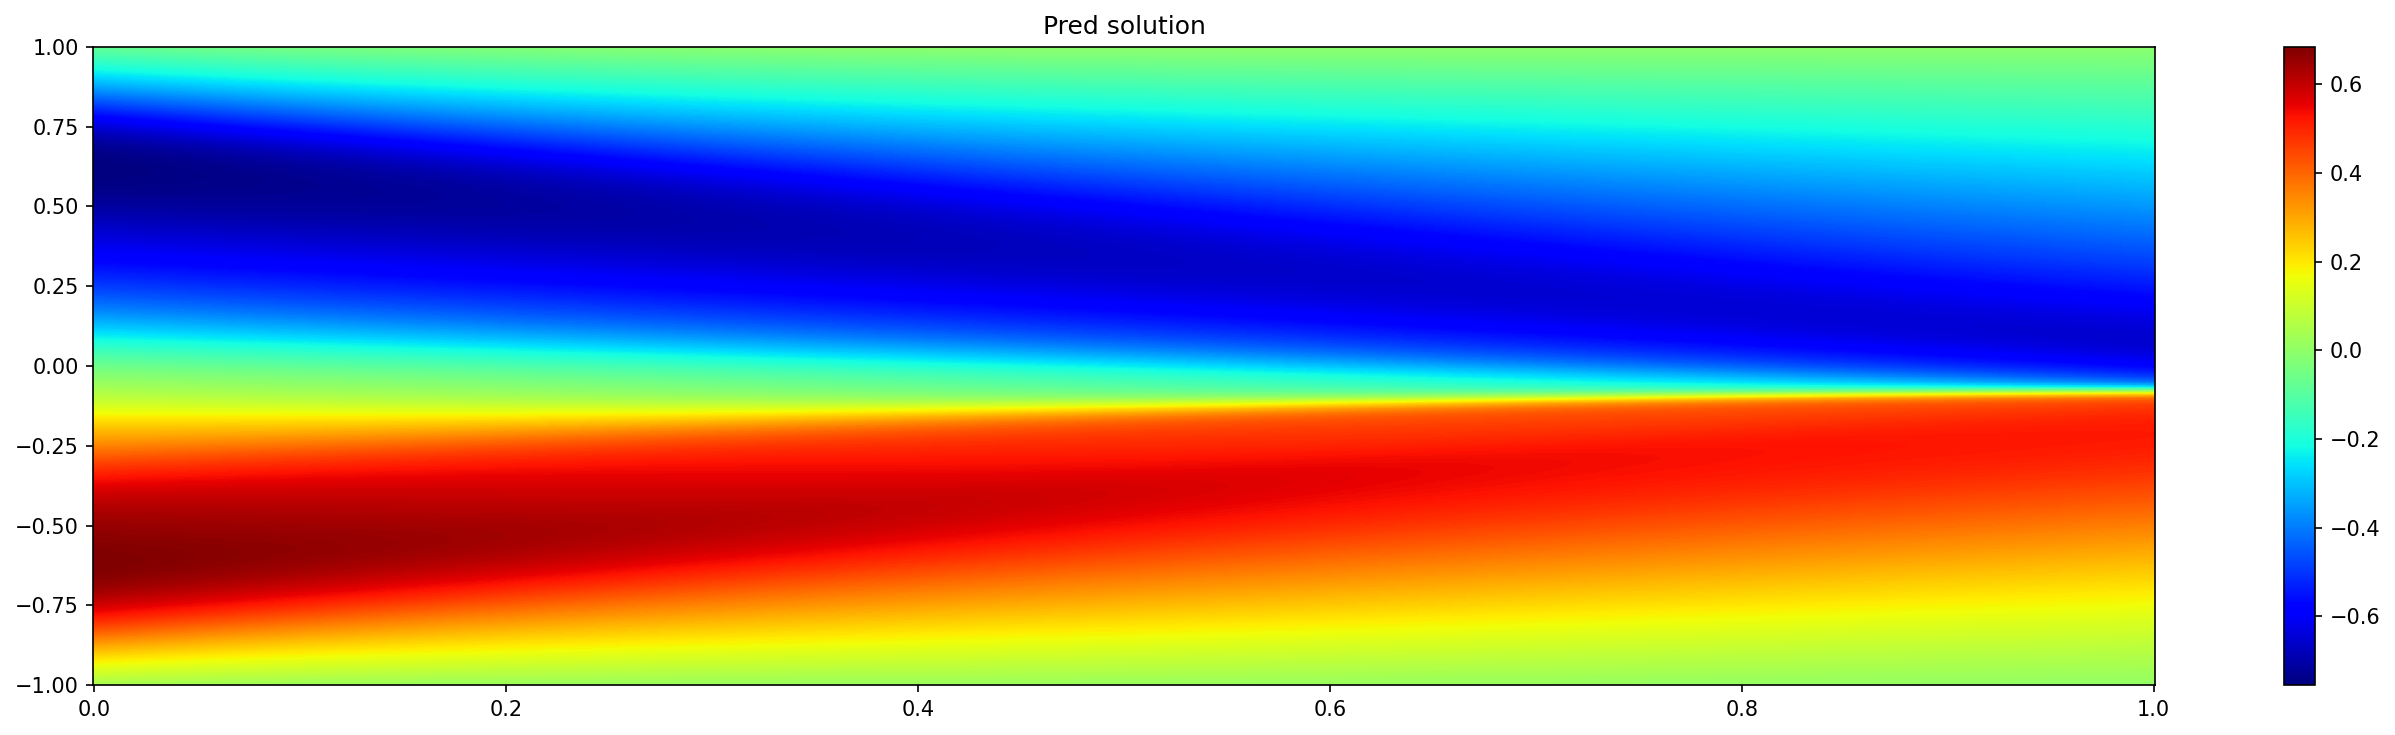

In [11]:
Tg, Xg, pred = test_pinn_solution(model, N_test=1024)

plt.figure(figsize=(18,5), dpi=150)

# ---- Exact ----
plt.title("Pred solution")
plt.pcolormesh(Tg, Xg, pred, shading='auto', cmap='jet')
plt.colorbar()
plt.tight_layout()
plt.show()